In [1]:
!py -3.9 -m pip install numpy pandas matplotlib pillow opencv-python imutils torch giotto-tda


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\Shantanu\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip


In [3]:
!py -3.9 -m pip install ipykernel
!py -3.9 -m ipykernel install --user --name py39 --display-name "Python 3.9"


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\Shantanu\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip


Installed kernelspec py39 in C:\Users\Shantanu\AppData\Roaming\jupyter\kernels\py39


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
import cv2
import imutils
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from gtda.homology import CubicalPersistence
from gtda.diagrams import PersistenceLandscape

In [7]:
!cd "C:\\Program Files\\MATLAB\\R2025a\\extern\\engines\\python" && python setup.py install

running install
running bdist_egg
running egg_info


C:\Users\Shantanu\anaconda3\Lib\site-packages\setuptools\_distutils\cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()
C:\Users\Shantanu\anaconda3\Lib\site-packages\setuptools\_distutils\cmd.py:66: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` and ``easy_install``.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://g

In [9]:
import sys
sys.path.append(r"C:\Users\Shantanu\anaconda3\lib\site-packages\matlabengine-25.1-py3.12.egg")
import matlab.engine

eng = matlab.engine.start_matlab()

In [157]:
"""
* Performs k-fold cross validation on the input data and labels.

* Parameters:
    k: The number of folds to split the data into.
    inputs: The input data.
    labels: The labels for the input data.

* Returns:
    A list of batches, where each
    batch is a list of tuples containing
    the input data and its corresponding label.
"""
def k_fold_cross_validation_split(k, inputs, labels):
  batches = []

  input_array = np.array(inputs)
  label_array = np.array(labels)
  batch_size = len(input_array) // k
  remaining_data = len(input_array) % k

  for i in range(k):
    batch = []

    print(f'\n-----------------Batch {i + 1} of {k}-----------------')

    for j in range(batch_size):
      index = i * batch_size + j
      batch.append((input_array[index], label_array[index]))

      if j == (batch_size // 4):
        print(f'Added {j + 1} data points to this batch.')
      elif j == (batch_size // 2):
        print(f'Added {j + 1} data points to this batch.')
      elif j == (batch_size * 3 // 4):
        print(f'Added {j + 1} data points to this batch.')

    print(f'Added {batch_size} data points to this batch.')
    batches.append(batch)

  for i in range(len(input_array) - remaining_data, len(input_array)):
    batches[len(batches) - 1].append((input_array[i], label_array[i]))

  if remaining_data > 0:
    print(f'Added {batch_size + remaining_data} data points to the last batch.')

  return batches

In [159]:
# Initialize a string containing the path to the training images.
training_path = "brain_mri_dataset/Training/"

# Initialize a string containing the path to the testing images.
testing_path = "brain_mri_dataset/Testing/"

# Initialize a list containing the four possible labels.
labels = ["glioma", "meningioma", "notumor", "pituitary"]

# Initialize a list to contain the training images.
training_images = []

# Initialize a list containing the testing images.
testing_images = []

# Iterate through the labels.
for label in labels:

    # Set a variable to the directory of a label's training images.
    label_dir = training_path + label

    # Iterate over the images of the current label.
    for image in os.listdir(label_dir):

        # Skip the file if its is called .ipynb_checkpoints
        if image == ".ipynb_checkpoints":
            continue

        # Store the relative path to a specific image.
        image_path = label_dir + "/" + image

        # Add the relative path to the list of training images.
        training_images.append(image_path)

    # Set a variable to the directory of a label's testing images.
    label_dir = testing_path + label

    # Iterate over the images of the current label.
    for image in os.listdir(label_dir):

        # Skip the file if its is called .ipynb_checkpoints
        if image == ".ipynb_checkpoints":
            continue

        # Store the relative path to a specific image.
        image_path = label_dir + "/" + image

        # Add the relative path to the list of testing images.
        testing_images.append(image_path)

In [161]:
# Shuffle the list of training images.
random.shuffle(training_images)

# Shuffle the list of testing images.
random.shuffle(testing_images)

In [163]:
# Initialize a list to store the label of each corresponding training image.
training_labels = []

testing_labels = []

# Iterate over the training images and extract its label.
for image in training_images:
    if "glioma" in image:
        training_labels.append("glioma")
    elif "meningioma" in image:
        training_labels.append("meningioma")
    elif "notumor" in image:
        training_labels.append("notumor")
    else:
        training_labels.append("pituitary")

for image in testing_images:
    if "glioma" in image:
        testing_labels.append([1,0,0,0])
    elif "meningioma" in image:
        testing_labels.append([0,1,0,0])
    elif "notumor" in image:
        testing_labels.append([0,0,1,0])
    else:
        testing_labels.append([0,0,0,1])

In [165]:
# Tune the value of k to split the training data into k batches.
k = 10

# Perform k-fold cross validation on the training data.
training_batches = k_fold_cross_validation_split(k, training_images, training_labels)


-----------------Batch 1 of 10-----------------
Added 143 data points to this batch.
Added 286 data points to this batch.
Added 429 data points to this batch.
Added 571 data points to this batch.

-----------------Batch 2 of 10-----------------
Added 143 data points to this batch.
Added 286 data points to this batch.
Added 429 data points to this batch.
Added 571 data points to this batch.

-----------------Batch 3 of 10-----------------
Added 143 data points to this batch.
Added 286 data points to this batch.
Added 429 data points to this batch.
Added 571 data points to this batch.

-----------------Batch 4 of 10-----------------
Added 143 data points to this batch.
Added 286 data points to this batch.
Added 429 data points to this batch.
Added 571 data points to this batch.

-----------------Batch 5 of 10-----------------
Added 143 data points to this batch.
Added 286 data points to this batch.
Added 429 data points to this batch.
Added 571 data points to this batch.

--------------

In [167]:
# Examine the training_batches structure.
training_batches

[[('brain_mri_dataset/Training/pituitary/Tr-pi_0293.jpg', 'pituitary'),
  ('brain_mri_dataset/Training/pituitary/Tr-pi_0279.jpg', 'pituitary'),
  ('brain_mri_dataset/Training/notumor/Tr-no_0048.jpg', 'notumor'),
  ('brain_mri_dataset/Training/glioma/Tr-gl_0535.jpg', 'glioma'),
  ('brain_mri_dataset/Training/pituitary/Tr-pi_1183.jpg', 'pituitary'),
  ('brain_mri_dataset/Training/pituitary/Tr-pi_1239.jpg', 'pituitary'),
  ('brain_mri_dataset/Training/notumor/Tr-no_0895.jpg', 'notumor'),
  ('brain_mri_dataset/Training/glioma/Tr-gl_0610.jpg', 'glioma'),
  ('brain_mri_dataset/Training/meningioma/Tr-me_0371.jpg', 'meningioma'),
  ('brain_mri_dataset/Training/meningioma/Tr-me_0718.jpg', 'meningioma'),
  ('brain_mri_dataset/Training/meningioma/Tr-me_0592.jpg', 'meningioma'),
  ('brain_mri_dataset/Training/pituitary/Tr-pi_0420.jpg', 'pituitary'),
  ('brain_mri_dataset/Training/glioma/Tr-gl_1151.jpg', 'glioma'),
  ('brain_mri_dataset/Training/glioma/Tr-gl_0047.jpg', 'glioma'),
  ('brain_mri_data

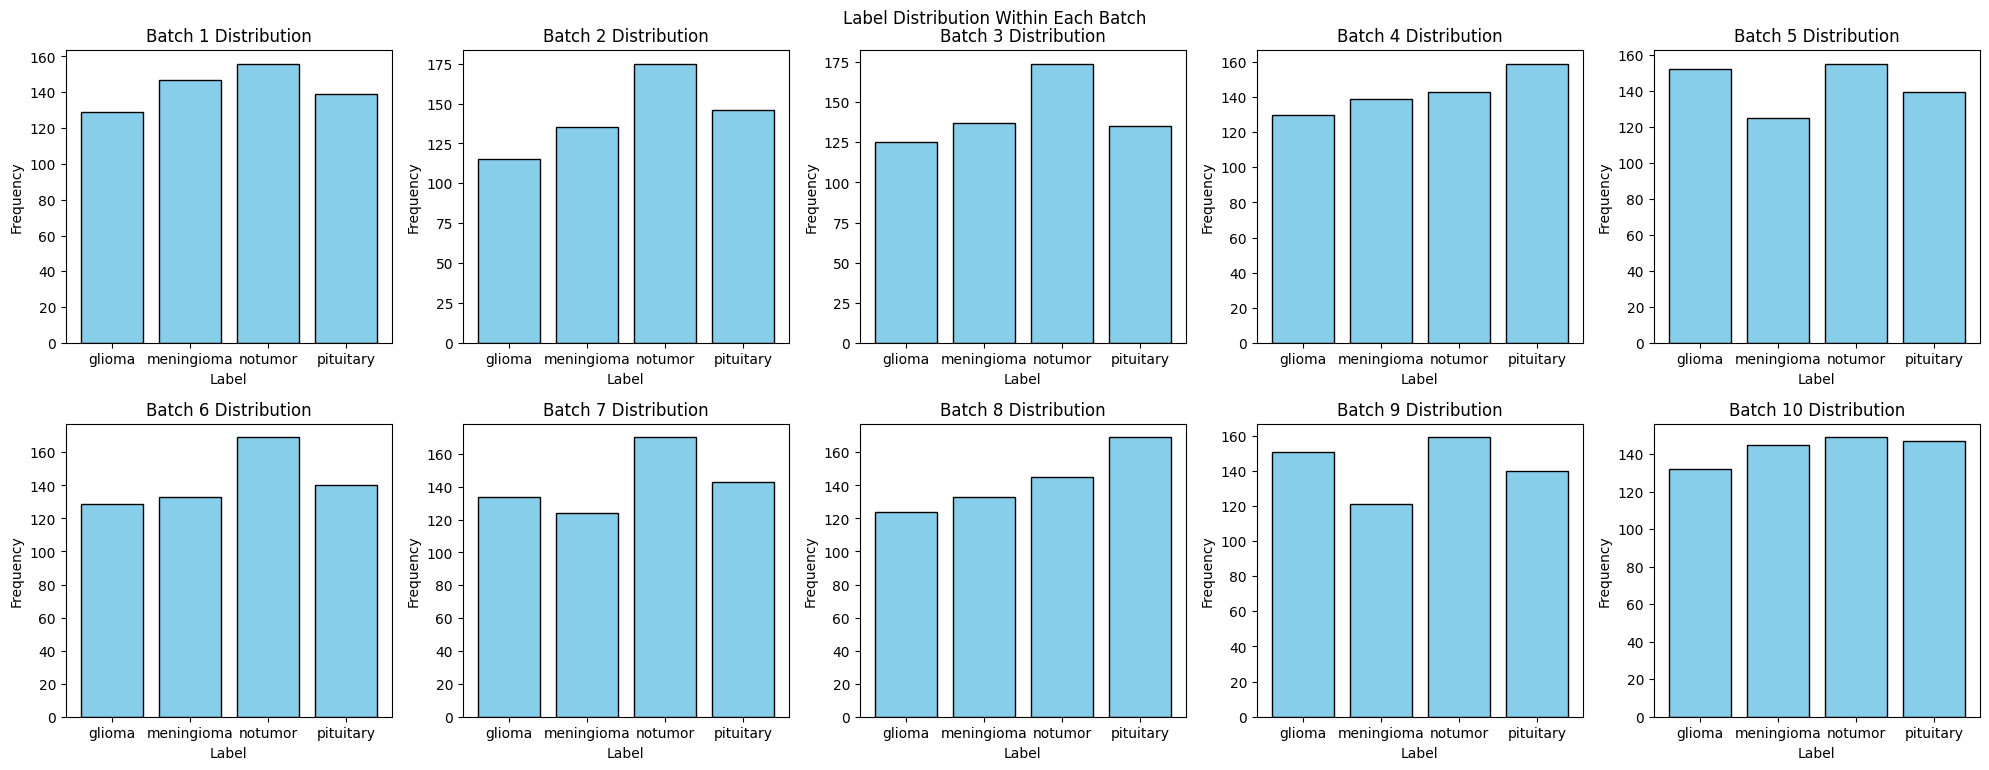

In [169]:
# Plot the distribution of the labels within each batch.
plt.figure(figsize=(20, 15))
plt.suptitle("Label Distribution Within Each Batch")

# Iterate over the batches.
for i in range(len(training_batches)):

    # Initialize a dictionary to keep track of the count of each label in the current batch.
    label_counts = dict({})

    # Iterate over the images in the current batch and count the labels.
    for image in training_batches[i]:
        if image[1] in label_counts:
            label_counts[image[1]] += 1
        else:
            label_counts[image[1]] = 1

    # Extract the counts for each label into a list.
    counts = [
        label_counts[labels[0]],
        label_counts[labels[1]],
        label_counts[labels[2]],
        label_counts[labels[3]]
    ]

    # Plot the distribution of each batch.
    plt.subplot(4, 5, i + 1)
    plt.bar(labels, counts, edgecolor="black", color="skyblue")
    plt.xlabel("Label")
    plt.ylabel("Frequency")
    plt.title("Batch " + str(i + 1) + " Distribution")

plt.tight_layout()

In [171]:
torch.manual_seed(42)

class PersistenceLandscapeNN(nn.Module):
    def __init__(self):
        super(PersistenceLandscapeNN, self).__init__()

        # Linear Layers
        self.layer1 = nn.Linear(500, 500)
        self.layer2 = nn.Linear(500, 250)
        self.layer3 = nn.Linear(250, 125)
        self.layer4 = nn.Linear(125, 62)
        self.layer5 = nn.Linear(62, 31)
        self.layer6 = nn.Linear(31, 15)
        self.layer7 = nn.Linear(15, 7)
        self.layer8 = nn.Linear(7, 4)

        # Batch Norm Layers
        self.bn1 = nn.BatchNorm1d(500)
        self.bn2 = nn.BatchNorm1d(500)
        self.bn3 = nn.BatchNorm1d(250)
        self.bn4 = nn.BatchNorm1d(125)
        self.bn5 = nn.BatchNorm1d(62)
        self.bn6 = nn.BatchNorm1d(31)
        self.bn7 = nn.BatchNorm1d(15)
        self.bn8 = nn.BatchNorm1d(7)
        self.bn9 = nn.BatchNorm1d(4)

        # Activation Layers
        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        # First Layer
        x = self.bn1(x)
        x = self.layer1(x)
        x = self.sigmoid(x)

        # Second Layer
        x = self.bn2(x)
        x = self.layer2(x)
        x = self.relu(x)

        # Third Layer
        x = self.bn3(x)
        x = self.layer3(x)
        x = self.sigmoid(x)

        # Fourth Layer
        x = self.bn4(x)
        x = self.layer4(x)
        x = self.relu(x)

        # Fifth Layer
        x = self.bn5(x)
        x = self.layer5(x)
        x = self.sigmoid(x)

        # Sixth Layer
        x = self.bn6(x)
        x = self.layer6(x)
        x = self.relu(x)

        # Seventh Layer
        x = self.bn7(x)
        x = self.layer7(x)
        x = self.sigmoid(x)

        # Eighth Layer
        x = self.bn8(x)
        x = self.layer8(x)
        x = self.relu(x)

        # Ninth Layer
        # x = self.bn9(x)

        # Output Layer
        x = self.softmax(x)

        return x

In [173]:
"""
Finds the extreme points on the image and crops the rectangular out of them
"""
def crop_img(gray, size):
    if len(size) > 2:
        gray = cv2.cvtColor(gray, cv2.COLOR_RGB2GRAY)
    
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    # threshold the image, then perform a series of erosions +
    # dilations to remove any small regions of noise
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)
    
    # find contours in thresholded image, then grab the largest one
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)
    
    # find the extreme points
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])
    ADD_PIXELS = 0
    new_img = gray[extTop[1]-ADD_PIXELS:extBot[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()
    
    return new_img

def crop_and_resize(image_path):       
    # Load and preprocess the image
    IMG_SIZE = 256
    image = Image.open(image_path).convert('L')
    shape = tuple(image.size)

    image_np_array = np.array(image)

    cropped_skull = crop_img(image_np_array, shape)
    resized = cv2.resize(cropped_skull, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    return resized

In [175]:
def save_cropped_image(img, original_path):
    folder = "CROPPED_AND_RESIZED"
    filename = os.path.basename(original_path)

    new_path = os.path.join(folder, filename)
    os.makedirs(folder, exist_ok=True)

    cv2.imwrite(new_path, img)

    return new_path

def save_skull_stripped_image(img, original_path):
    folder = "SKULL_STRIPPED_IMAGES"
    filename = os.path.basename(original_path)

    new_path = os.path.join(folder, filename)
    os.makedirs(folder, exist_ok=True)

    cv2.imwrite(new_path, img)

    return new_path

def skull_stripping(img_path):
    # Use current directory where notebook and .m/.mat files are located
    eng.cd(os.path.abspath("Skull-stripping"), nargout=0)
    img_path = os.path.abspath(img_path)
    model_path = os.path.abspath("Skull-stripping/NIVE.mat")
    
    result = eng.nive_extract_brain(img_path, model_path)
    
    # Convert MATLAB array to NumPy
    # result is a 3D array in column-major (Fortran-style)
    shape = tuple(result.size)  # (height, width, channels)
    skull_np_array = np.array(result._data, dtype=np.uint8).reshape(shape, order='F')

    cropped_skull = crop_img(skull_np_array, shape)
    resized_skull = cv2.resize(cropped_skull, (200, 200), interpolation=cv2.INTER_AREA)

    return resized_skull

def CLAHE_persistence_landscape(gray_skull_stripped):
    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    clahe_skull = clahe.apply(gray_skull_stripped)
    
    # Normalize to [0, 1] for GTDA
    normalized_clahe_skull = clahe_skull / 255.0
    normalized_clahe_skull[normalized_clahe_skull < 0.02] = 0.5
    
    # Reshape for giotto-tda
    X_clahe_skull = normalized_clahe_skull[np.newaxis, :, :]  # Shape: (1, H, W)
    
    # Compute Cubical Persistence
    cp_skull = CubicalPersistence(homology_dimensions=(0, 1))
    cp_skull.fit(X_clahe_skull)
    diagrams_skull = cp_skull.fit_transform(X_clahe_skull)

    diagram = diagrams_skull[0]
    diagram_h0 = diagram[np.isclose(diagram[:, 2], 0)]
    diagram_h1 = diagram[np.isclose(diagram[:, 2], 1)]

    # Compute persistence landscape
    pl = PersistenceLandscape(n_layers=5, n_bins=50) 
    landscape_h0 = pl.fit_transform([diagram_h0])
    landscape_h1 = pl.fit_transform([diagram_h1])

    # Convert the persistence landscape to a feature vector
    features_h0 = landscape_h0[0].flatten()
    features_h1 = landscape_h1[0].flatten()

    return np.concatenate((features_h0, features_h1))

In [177]:
from concurrent.futures import ThreadPoolExecutor

class Preprocessor:
    def __init__(self, batch_length):
        self.cnt = 1
        self.batch_length = batch_length
    
    def extract_landscapes(self, image):
        image_path = image[0]
        cropped_img = crop_and_resize(image_path)
        cropped_img_path = save_cropped_image(cropped_img, image_path)
        skull = skull_stripping(cropped_img_path)
        skull_stripped_img_path = save_skull_stripped_image(skull, image_path)
        landscapes = CLAHE_persistence_landscape(skull)
        print("-> [" + str(self.cnt) + "/" + str(self.batch_length) + "] EXTRACTED PERSISTENCE LANDSCAPE FOR " + image_path)
        self.cnt += 1
        return landscapes
    
    def extract_vectors(self, image):
        label = image[1]
        y = [0.,0.,0.,0.]
        
        for index in range(len(labels)):
            if labels[index] == label:
                y[index] = 1.
                break
        
        return y

In [203]:
model = PersistenceLandscapeNN()
learning_rate = 0.1
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [205]:
batch_index = 9
batch = training_batches[batch_index]
i = 0

if len(batch) % 2:
    batch.pop()

model.train()

while i < 40:
    print("\n-------------------------------------------------------------IMAGE PAIR " + str((i // 2) + 1) + "--------------------------------------------")
    preprocessor = Preprocessor(2)
    images = [
        batch[i],
        batch[i + 1]
    ]

    with ThreadPoolExecutor() as executor:
        X = executor.map(preprocessor.extract_landscapes, images)
        y = executor.map(preprocessor.extract_vectors, images)
    
    X = torch.tensor(np.array(list(X)), dtype=torch.float32)
    y = torch.tensor(np.array(list(y)), dtype=torch.float32)

    print(X.shape)
    
    predictions = model(X)
    loss_value = loss(predictions, y)
    loss_value.backward()
    optimizer.step()

    i += 2


-------------------------------------------------------------IMAGE PAIR 1--------------------------------------------
-> [1/2] EXTRACTED PERSISTENCE LANDSCAPE FOR brain_mri_dataset/Training/pituitary/Tr-pi_1193.jpg
-> [2/2] EXTRACTED PERSISTENCE LANDSCAPE FOR brain_mri_dataset/Training/glioma/Tr-gl_1289.jpg
torch.Size([2, 500])

-------------------------------------------------------------IMAGE PAIR 2--------------------------------------------
-> [1/2] EXTRACTED PERSISTENCE LANDSCAPE FOR brain_mri_dataset/Training/glioma/Tr-gl_0311.jpg
-> [2/2] EXTRACTED PERSISTENCE LANDSCAPE FOR brain_mri_dataset/Training/pituitary/Tr-pi_1424.jpg
torch.Size([2, 500])

-------------------------------------------------------------IMAGE PAIR 3--------------------------------------------
-> [1/2] EXTRACTED PERSISTENCE LANDSCAPE FOR brain_mri_dataset/Training/glioma/Tr-gl_0207.jpg
-> [2/2] EXTRACTED PERSISTENCE LANDSCAPE FOR brain_mri_dataset/Training/notumor/Tr-no_1142.jpg
torch.Size([2, 500])

--------

In [207]:
testing_images

['brain_mri_dataset/Testing/notumor/Te-no_0391.jpg',
 'brain_mri_dataset/Testing/meningioma/Te-me_0046.jpg',
 'brain_mri_dataset/Testing/pituitary/Te-pi_0051.jpg',
 'brain_mri_dataset/Testing/notumor/Te-no_0200.jpg',
 'brain_mri_dataset/Testing/notumor/Te-no_0390.jpg',
 'brain_mri_dataset/Testing/meningioma/Te-me_0187.jpg',
 'brain_mri_dataset/Testing/notumor/Te-no_0210.jpg',
 'brain_mri_dataset/Testing/pituitary/Te-pi_0235.jpg',
 'brain_mri_dataset/Testing/notumor/Te-no_0159.jpg',
 'brain_mri_dataset/Testing/notumor/Te-no_0243.jpg',
 'brain_mri_dataset/Testing/glioma/Te-gl_0116.jpg',
 'brain_mri_dataset/Testing/notumor/Te-no_0056.jpg',
 'brain_mri_dataset/Testing/meningioma/Te-me_0301.jpg',
 'brain_mri_dataset/Testing/glioma/Te-gl_0137.jpg',
 'brain_mri_dataset/Testing/pituitary/Te-piTr_0001.jpg',
 'brain_mri_dataset/Testing/pituitary/Te-pi_0073.jpg',
 'brain_mri_dataset/Testing/notumor/Te-no_0332.jpg',
 'brain_mri_dataset/Testing/notumor/Te-no_0339.jpg',
 'brain_mri_dataset/Testing/n

In [209]:
testing_images_subset = testing_images[0:40]
preprocessor = Preprocessor(40)
cnt = 0

model.eval()

for i in range(len(testing_images_subset)):
    if "glioma" in testing_images_subset[i]:
        testing_images_subset[i] = (testing_images_subset[i], "glioma")
    elif "meningioma" in testing_images_subset[i]:
        testing_images_subset[i] = (testing_images_subset[i], "meningioma")
    elif "notumor" in testing_images_subset[i]:
        testing_images_subset[i] = (testing_images_subset[i], "notumor")
    else:
        testing_images_subset[i] = (testing_images_subset[i], "pituitary")

with ThreadPoolExecutor() as executor:
    X = executor.map(preprocessor.extract_landscapes, testing_images_subset)
    y = executor.map(preprocessor.extract_vectors, testing_images_subset)

X = list(X)
y = np.array(list(y))

for i in range(len(X)):
    input = torch.tensor([X[i]], dtype=torch.float32)
    prediction = model(input)

    print("[" + str(i + 1) + "/40] " + testing_images[i][0] + ": " + str(prediction) + " ------VS.------ " + str(y[i]))

    if y[i].argmax() == prediction.detach().numpy().argmax():
        cnt += 1

print("Current Accuracy: " + str(cnt / 40))

-> [1/40] EXTRACTED PERSISTENCE LANDSCAPE FOR brain_mri_dataset/Testing/notumor/Te-no_0391.jpg
-> [2/40] EXTRACTED PERSISTENCE LANDSCAPE FOR brain_mri_dataset/Testing/meningioma/Te-me_0046.jpg
-> [3/40] EXTRACTED PERSISTENCE LANDSCAPE FOR brain_mri_dataset/Testing/notumor/Te-no_0390.jpg
-> [4/40] EXTRACTED PERSISTENCE LANDSCAPE FOR brain_mri_dataset/Testing/notumor/Te-no_0056.jpg
-> [5/40] EXTRACTED PERSISTENCE LANDSCAPE FOR brain_mri_dataset/Testing/meningioma/Te-me_0301.jpg
-> [6/40] EXTRACTED PERSISTENCE LANDSCAPE FOR brain_mri_dataset/Testing/pituitary/Te-piTr_0001.jpg
-> [7/40] EXTRACTED PERSISTENCE LANDSCAPE FOR brain_mri_dataset/Testing/pituitary/Te-pi_0051.jpg
-> [8/40] EXTRACTED PERSISTENCE LANDSCAPE FOR brain_mri_dataset/Testing/pituitary/Te-pi_0235.jpg
-> [9/40] EXTRACTED PERSISTENCE LANDSCAPE FOR brain_mri_dataset/Testing/notumor/Te-no_0200.jpg
-> [10/40] EXTRACTED PERSISTENCE LANDSCAPE FOR brain_mri_dataset/Testing/notumor/Te-no_0243.jpg
-> [11/40] EXTRACTED PERSISTENCE LA